<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#P1)
- [2. Data](#P2)
- [3. Multilabel Classification](#P3)
    - [3.1 Specific Data Preparation](#P3.1)
    - [3.2 Model Implementation](#P3.2)
    - [3.3 Model Evaluation](#P3.3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="P1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import matplotlib.pyplot as plt
import plotly as px
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier


# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="P2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="P3"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation</font> <a class="anchor" id="P3.1"></a>
  
[Back to TOC](#toc)

In [7]:
dataset["categoryName"].value_counts().reset_index()

,categoryName,count
0,Mexican restaurant,8959
1,Fast food restaurant,5325
2,Italian restaurant,5108
3,American restaurant,5049
4,Pizza restaurant,4560
5,Breakfast restaurant,2491
6,Chinese restaurant,2484
7,Seafood restaurant,2048
8,Hamburger restaurant,1979
9,New American restaurant,1903


In [8]:
## Create dummy columns to assess msg_len and nr_sents
info = pd.DataFrame()
info["msg_len"] = dataset["text"].map(lambda content : len(str(content)))
info["sents"] = dataset["text"].map(lambda content :\
                                                                  sent_tokenizer.tokenize(str(content)))
info["nr_sents"] = info["sents"].map(lambda content : len(content))

In [9]:
info.describe()
#is there reviews with 0 on len and 0 sentences?

,msg_len,nr_sents
count,53566.000000,53566.000000
mean,183.570380,3.246910
std,240.235404,3.085194
min,1.000000,1.000000
25%,46.000000,1.000000
50%,105.000000,2.000000
75%,228.000000,4.000000
max,4114.000000,45.000000


In [10]:
histogram_chart(info, "msg_len", "Length per review", "Message Length", bins = 100)

In [11]:
histogram_chart(info, "nr_sents", "Number of Sentences per review", "Number of Sentences")

In [12]:
## Extract the unique genres

unique_cuisine = []

for restaurants_cuisines in dataset["categoryName"]:
        if restaurants_cuisines not in unique_cuisine:
            unique_cuisine.append(restaurants_cuisines)

## Create a scratch dataset - "dataset_explore" - to plot the number of restaurants by category and to generate TF-IDF word clouds by label

dataset_explore = pd.DataFrame()
dataset_explore["text"] = dataset["text"]

for label in unique_cuisine:
    dataset_explore["has_label_{}".format(label)] = dataset["categoryName"].map(lambda labels_list : 1 if label in labels_list else 0)

## Assess the "dataset_explore" dataset

dataset_explore

,text,has_label_Seafood restaurant,has_label_Italian restaurant,has_label_Mexican restaurant,has_label_New American restaurant,has_label_Japanese restaurant,has_label_Fast food restaurant,has_label_American restaurant,has_label_Hamburger restaurant,has_label_Breakfast restaurant,has_label_Indian restaurant,has_label_Mediterranean restaurant,has_label_Thai restaurant,has_label_Steak house,has_label_Barbecue restaurant,has_label_Bar & grill,has_label_Chinese restaurant,has_label_Pizza restaurant,has_label_Chicken restaurant,has_label_Sandwich shop
0,"One word amazing!! The red fish, halibut, fr...",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,First time here and the food is great and the ...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,I recently had the pleasure of dining at Optim...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Beautiful atmosphere and delicious food. All o...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,We had a wonderful dinner at the Optimist. Our...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53561,Friday night dinner was Chicken Francaise. Jor...,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
53562,Great dinner.... Yay Jordan!!!!!!,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
53563,Jordan was our server and he was fantastic! Gr...,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
53564,Jordan was an amazing server! Great delicious...,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


<Axes: >

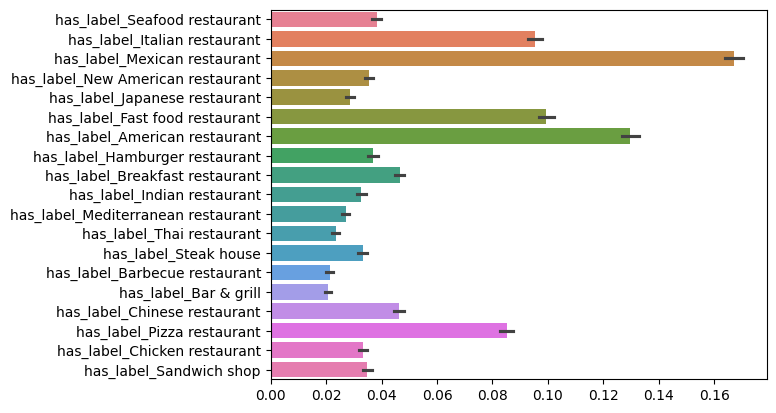

In [13]:
sns.barplot(dataset_explore, orient="h")

In [14]:
category_reviews = dataset.groupby("categoryName")["text"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews["text"])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_reviews["categoryName"],
    columns=category_reviews["categoryName"]
)

In [15]:
heatmap_chart(similarity_df,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

In [16]:
dataset['cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=True,            # Keep stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food", "great", "good", "service", "place"],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

In [17]:
category_reviews_cleaned = dataset.groupby("categoryName")["cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews_cleaned["cleaned_review_body"])

similarity_matrix_cleaned = cosine_similarity(tfidf_matrix)

similarity_df_cleaned = pd.DataFrame(
    similarity_matrix_cleaned,
    index=category_reviews_cleaned["categoryName"],
    columns=category_reviews_cleaned["categoryName"]
)

In [18]:
heatmap_chart(similarity_df_cleaned,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

In [19]:
dataset[['text', 'cleaned_review_body']].iloc[49].values

array(['Was just there to pick a friend up. Nice clean modern environment. Parking was tight but worth it. Will come back for entree',
       'pick friend nice clean modern environment parking tight worth come back entree'],
      dtype=object)

In [20]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['cleaned_review_body'])
words = vectorizer.get_feature_names_out()

category_word_freq = []

for cat in dataset['categoryName'].unique():
    texts = dataset[dataset['categoryName'] == cat]['cleaned_review_body']
    X_cat = vectorizer.transform(texts)
    counts = X_cat.sum(axis=0).A1
    freq = dict(zip(words, counts))
    top_words = Counter(freq).most_common(15)  # top 15 per category

    for word, count in top_words:
        category_word_freq.append({'category': cat, 'word': word, 'count': count})


df_freq = pd.DataFrame(category_word_freq)
df_freq.head(15)


,category,word,count
0,Seafood restaurant,seafood,350
1,Seafood restaurant,back,346
2,Seafood restaurant,shrimp,337
3,Seafood restaurant,time,321
4,Seafood restaurant,delicious,248
5,Seafood restaurant,restaurant,245
6,Seafood restaurant,amazing,228
7,Seafood restaurant,fish,226
8,Seafood restaurant,excellent,215
9,Seafood restaurant,nice,202


In [21]:
treemap_chart(df_freq,
              path_col = [px.Constant('Atlanta Restaurants Categories'), 'category', 'word'],
              value_col='count',
              title = 'Most frequent words per cuisine category in Atlanta restaurant reviews')

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

In [22]:
'''bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), token_pattern=r"(?u)\b\w+\b")

dataset_tfidf_td_matrix = bigram_tfidf_vectorizer.fit_transform(dataset["cleaned_review_body"]).toarray()
dataset["tfidf_vector"] = dataset_tfidf_td_matrix.tolist()
dataset.head()'''

bigram_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    token_pattern=r"(?u)\b\w+\b",
    min_df=5,                     # evita sparse gigante desnecessária
    max_df=0.8
)


X = bigram_tfidf_vectorizer.fit_transform(dataset["cleaned_review_body"])
'''row = X[0]
indices = row.indices
values = row.data
tokens = bigram_tfidf_vectorizer.get_feature_names_out()

for idx, val in zip(indices, values):
    print(tokens[idx], "→", val)'''

'row = X[0]\nindices = row.indices\nvalues = row.data\ntokens = bigram_tfidf_vectorizer.get_feature_names_out()\n\nfor idx, val in zip(indices, values):\n    print(tokens[idx], "→", val)'

In [23]:
encoder = LabelEncoder()
dataset['label'] = encoder.fit_transform(dataset['categoryName'])

In [25]:
y = dataset["label"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
precisions_micro = []
precisions_macro = []
recalls_micro = []
recalls_macro = []
f1s_micro = []
f1s_macro = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    ovm = OneVsRestClassifier(
        LogisticRegression(solver='lbfgs', random_state=0, class_weight="balanced")
    )
    ovm.fit(X_train, y_train)
    
    # Predição
    y_pred = ovm.predict(X_test)

    # Métricas
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions_micro.append(precision_score(y_test, y_pred, average='micro'))
    precisions_macro.append(precision_score(y_test, y_pred, average='macro'))
    recalls_micro.append(recall_score(y_test, y_pred, average='micro'))
    recalls_macro.append(recall_score(y_test, y_pred, average='macro'))
    f1s_micro.append(f1_score(y_test, y_pred, average='micro'))
    f1s_macro.append(f1_score(y_test, y_pred, average='macro'))

# Pega os nomes originais das classes
target_names = encoder.classes_

# Resultados médios
print("Average accuracy:", np.mean(accuracies))
print("Average Precision (micro):", np.mean(precisions_micro))
print("Average Precision (macro):", np.mean(precisions_macro))
print("Average Recall (micro):", np.mean(recalls_micro))
print("Average Recall (macro):", np.mean(recalls_macro))
print("Average F1-score (micro):", np.mean(f1s_micro))
print("AverageF1-score (macro):", np.mean(f1s_macro))

# Para ver relatório detalhado em um fold específico
print("\nClassification Report (last fold):\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de confusão
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Average accuracy: 0.4816861333670538
Average Precision (micro): 0.4816861333670538
Average Precision (macro): 0.4613291673860419
Average Recall (micro): 0.4816861333670538
Average Recall (macro): 0.4666569219502062
Average F1-score (micro): 0.4816861333670538
AverageF1-score (macro): 0.4613169798426037

Classification Report (last fold):

                          precision    recall  f1-score   support

     American restaurant       0.36      0.34      0.35      1010
             Bar & grill       0.28      0.34      0.31       222
     Barbecue restaurant       0.57      0.58      0.57       228
    Breakfast restaurant       0.36      0.42      0.39       499
      Chicken restaurant       0.37      0.44      0.40       356
      Chinese restaurant       0.40      0.43      0.42       496
    Fast food restaurant       0.43      0.57      0.49      1065
    Hamburger restaurant       0.57      0.57      0.57       395
       Indian restaurant       0.60      0.55      0.58       35

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="P3.3"></a>
  
[Back to TOC](#toc)